# 5. Eigenvalues and Eigenvectors

When a matrix acts on most vectors, both the direction and length change.  
But some special vectors only get **scaled** -- these are the **eigenvectors**, and the scale factor is the **eigenvalue**.

$$A \mathbf{v} = \lambda \mathbf{v}$$

This notebook builds geometric intuition for what eigenvectors look like and why they matter.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import ipywidgets as widgets
from IPython.display import display

%matplotlib inline

BLUE  = "#2196F3"
RED   = "#F44336"
GREEN = "#4CAF50"
GRAY  = "#BDBDBD"

def setup_ax(ax, lim=4, title=""):
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_aspect("equal")
    ax.grid(True, lw=0.4, alpha=0.5)
    ax.axhline(0, color="k", lw=0.4)
    ax.axvline(0, color="k", lw=0.4)
    if title:
        ax.set_title(title, fontsize=13)

## 5.1 Visualising the Eigenvector Property

We sample many unit vectors, apply the matrix, and draw both the original and transformed vector.  
The **eigenvectors** are the ones whose transformed version stays on the same line through the origin.

In [2]:
def plot_eigen_field(A, n_arrows=24):
    """
    Show how A acts on many unit vectors; highlight eigenvectors.

    Parameters
    ----------
    A : ndarray (2,2)
    n_arrows : int
    """
    vals, vecs = np.linalg.eig(A)
    has_real_eigen = np.all(np.isreal(vals))

    fig, ax = plt.subplots(figsize=(7, 7))
    setup_ax(ax, lim=4)

    theta = np.linspace(0, 2 * np.pi, n_arrows, endpoint=False)
    for th in theta:
        v = np.array([np.cos(th), np.sin(th)])
        Av = A @ v
        ax.annotate(
            "",
            xy=v,
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color=GRAY, lw=1),
        )
        ax.annotate(
            "",
            xy=Av,
            xytext=(0, 0),
            arrowprops=dict(arrowstyle="->", color=BLUE, lw=1.2, alpha=0.5),
        )

    if has_real_eigen:
        vals_r = vals.real
        vecs_r = vecs.real
        colors_ev = [RED, GREEN]
        for i in range(2):
            ev = vecs_r[:, i]
            ev_unit = ev / np.linalg.norm(ev)
            Aev = A @ ev_unit

            t = np.linspace(-4, 4, 2)
            ax.plot(
                t * ev_unit[0],
                t * ev_unit[1],
                "--",
                color=colors_ev[i],
                lw=1,
                alpha=0.5,
            )

            ax.annotate(
                "",
                xy=ev_unit,
                xytext=(0, 0),
                arrowprops=dict(arrowstyle="->", color=colors_ev[i], lw=3),
            )
            ax.annotate(
                "",
                xy=Aev,
                xytext=(0, 0),
                arrowprops=dict(
                    arrowstyle="->", color=colors_ev[i], lw=2, linestyle="--"
                ),
            )
            ax.text(
                ev_unit[0] + 0.15,
                ev_unit[1] + 0.15,
                f"λ={vals_r[i]:.2f}",
                color=colors_ev[i],
                fontsize=11,
                fontweight="bold",
            )

    legend_items = [
        mpatches.Patch(color=GRAY, label="Original unit vectors"),
        mpatches.Patch(color=BLUE, alpha=0.5, label="After applying A"),
    ]
    if has_real_eigen:
        legend_items.append(
            mpatches.Patch(
                color=RED, label=f"Eigenvector 1 (λ={vals.real[0]:.2f})"
            )
        )
        legend_items.append(
            mpatches.Patch(
                color=GREEN, label=f"Eigenvector 2 (λ={vals.real[1]:.2f})"
            )
        )
    else:
        legend_items.append(
            mpatches.Patch(
                color="purple", label=f"Complex eigenvalues: {vals[0]:.2f}"
            )
        )

    ax.legend(handles=legend_items, fontsize=10, loc="upper left")
    ax.set_title(
        f"Matrix A and its eigenvectors\ndet={np.linalg.det(A):.2f}, tr={np.trace(A):.2f}",
        fontsize=12,
    )
    plt.tight_layout()
    plt.show()

A = 
[[0 1]
 [1 0]]
Eigenvalues:  [ 1. -1.]
Eigenvectors (columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]
SVD: SVDResult(U=array([[ 0., -1.],
       [-1.,  0.]]), S=array([1., 1.]), Vh=array([[-1., -0.],
       [-0., -1.]]))


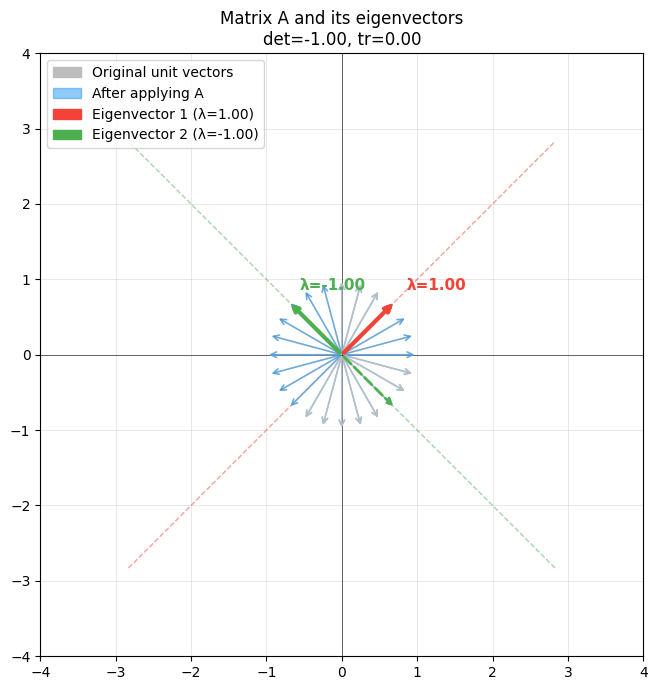

In [ ]:
A = np.array([[0, 1], [1, 0]])
print(f"A = \n{A}")
vals, vecs = np.linalg.eig(A)
print(f"Eigenvalues:  {vals}")
print(f"Eigenvectors (columns):\n{vecs}")
print(f"SVD: {np.linalg.svd(A)}")

plot_eigen_field(A)

## 5.2 Interactive Eigenvector Explorer

Change the matrix entries and watch the eigenvectors shift.

In [4]:
def interactive_eigen(a, b, c, d):
    A = np.array([[a, b], [c, d]])
    vals, _ = np.linalg.eig(A)
    print(f"Eigenvalues: {vals}")
    plot_eigen_field(A)


style = {"description_width": "initial"}
widgets.interact(
    interactive_eigen,
    a=widgets.FloatSlider(
        value=2, min=-3, max=3, step=0.1, description="a", style=style
    ),
    b=widgets.FloatSlider(
        value=1, min=-3, max=3, step=0.1, description="b", style=style
    ),
    c=widgets.FloatSlider(
        value=1, min=-3, max=3, step=0.1, description="c", style=style
    ),
    d=widgets.FloatSlider(
        value=2, min=-3, max=3, step=0.1, description="d", style=style
    ),
)

interactive(children=(FloatSlider(value=2.0, description='a', max=3.0, min=-3.0, style=SliderStyle(description…

<function __main__.interactive_eigen(a, b, c, d)>

## 5.3 Eigenvalues and Transformation Types

The eigenvalues tell you a lot about what the matrix *does*:

| Eigenvalues | Transformation type |
|-------------|--------------------|
| Both real, positive | Stretching along eigenvector directions |
| Both real, one negative | Stretching + reflection in one direction |
| Complex conjugate pair | Rotation (possibly with scaling) |
| Both equal to 1 | Identity (or shear, if not diagonalisable) |
| One eigenvalue = 0 | Projection / collapse onto a line |

Let us verify each case.

Stretching (λ=3, λ=1)
  Eigenvalues: [3. 1.]



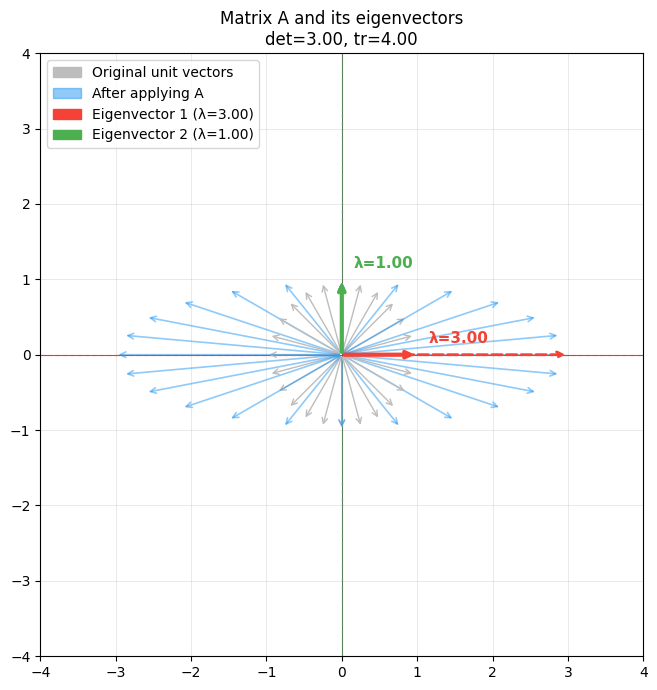

Stretch + reflect (λ=2, λ=-1)
  Eigenvalues: [ 2. -1.]



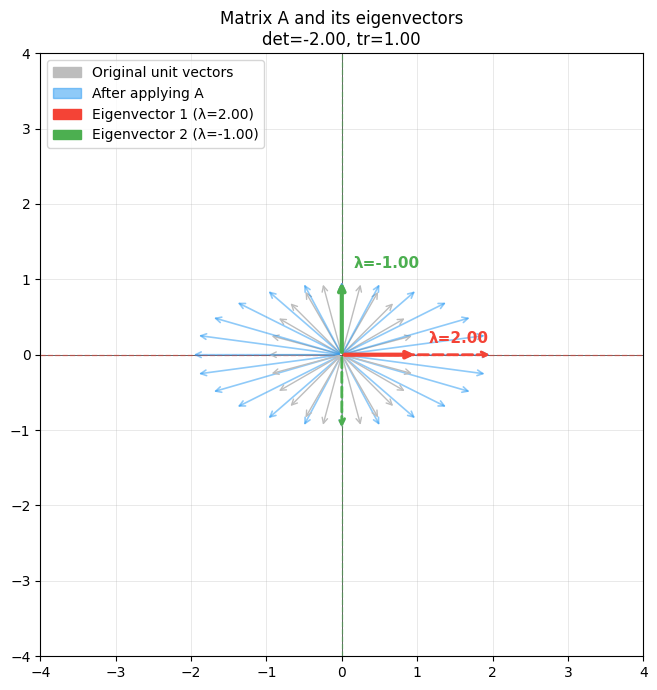

Pure rotation 90° (λ=±i)
  Eigenvalues: [0.+1.j 0.-1.j]



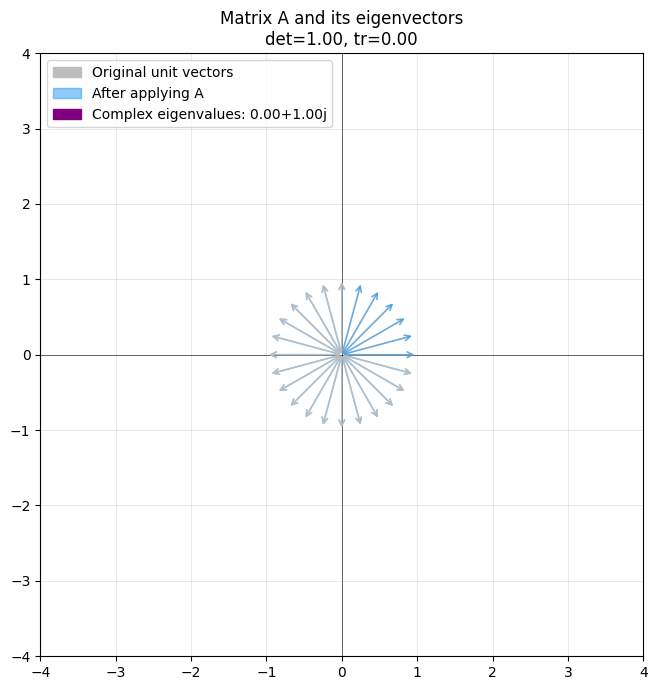

Projection onto x-axis (λ=1, λ=0)
  Eigenvalues: [1. 0.]



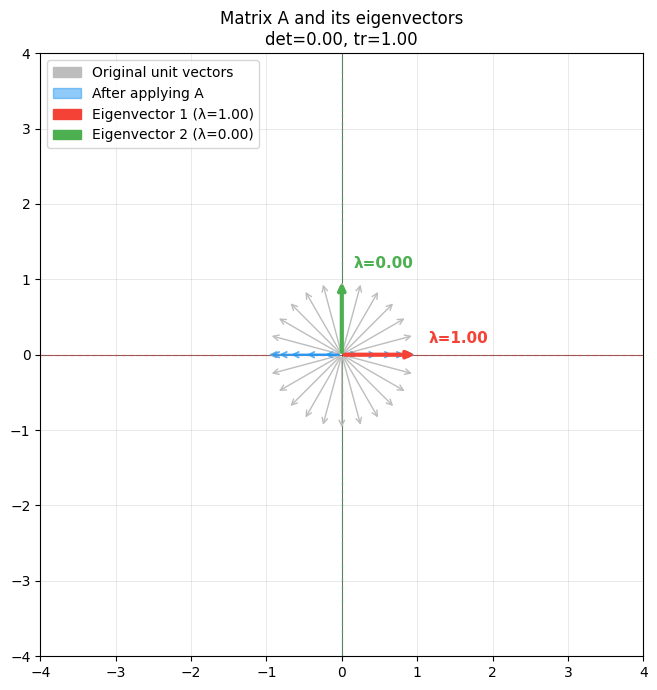

In [5]:
examples = [
    (np.array([[3, 0], [0, 1]]), "Stretching (λ=3, λ=1)"),
    (np.array([[2, 0], [0, -1]]), "Stretch + reflect (λ=2, λ=-1)"),
    (np.array([[0, -1], [1, 0]]), "Pure rotation 90° (λ=±i)"),
    (np.array([[1, 0], [0, 0]]), "Projection onto x-axis (λ=1, λ=0)"),
]

for A, desc in examples:
    vals, _ = np.linalg.eig(A)
    print(f"{desc}")
    print(f"  Eigenvalues: {vals}\n")
    plot_eigen_field(A)

## 5.4 Diagonalisation

If $A$ has $n$ linearly independent eigenvectors, we can write:

$$A = V \Lambda V^{-1}$$

where $V$ is the matrix of eigenvectors (as columns) and $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$.

**Geometric meaning:** change to the eigenvector coordinate system, scale each axis independently, then change back.

This is extremely useful because **powers** of $A$ become trivial:

$$A^k = V \Lambda^k V^{-1}$$

In [6]:
A = np.array([[2, 1], [1, 2]])

vals, V = np.linalg.eig(A)
Lambda = np.diag(vals)
V_inv = np.linalg.inv(V)

print("V (eigenvectors as columns):")
print(V)
print(f"\nΛ (eigenvalue diagonal):\n{Lambda}")
print(f"\nV Λ V⁻¹ = \n{V @ Lambda @ V_inv}")
print(f"\nOriginal A = \n{A}")
print(f"\nMatch: {np.allclose(A, V @ Lambda @ V_inv)}")

V (eigenvectors as columns):
[[ 0.70710678 -0.70710678]
 [ 0.70710678  0.70710678]]

Λ (eigenvalue diagonal):
[[3. 0.]
 [0. 1.]]

V Λ V⁻¹ = 
[[2. 1.]
 [1. 2.]]

Original A = 
[[2 1]
 [1 2]]

Match: True


In [7]:
print("Powers of A via diagonalisation:")
for k in [2, 5, 10]:
    Ak_diag = V @ np.diag(vals**k) @ V_inv
    Ak_direct = np.linalg.matrix_power(A, k)
    print(f"  A^{k} (diag) = \n{np.round(Ak_diag, 4)}")
    print(f"  A^{k} (direct) = \n{Ak_direct}")
    print(f"  Match: {np.allclose(Ak_diag, Ak_direct)}\n")

Powers of A via diagonalisation:
  A^2 (diag) = 
[[5. 4.]
 [4. 5.]]
  A^2 (direct) = 
[[5 4]
 [4 5]]
  Match: True

  A^5 (diag) = 
[[122. 121.]
 [121. 122.]]
  A^5 (direct) = 
[[122 121]
 [121 122]]
  Match: True

  A^10 (diag) = 
[[29525. 29524.]
 [29524. 29525.]]
  A^10 (direct) = 
[[29525 29524]
 [29524 29525]]
  Match: True



## 5.5 The Characteristic Polynomial

Eigenvalues are the roots of the **characteristic polynomial**:

$$\det(A - \lambda I) = 0$$

For a $2 \times 2$ matrix $A = \begin{pmatrix} a & b \\ c & d \end{pmatrix}$:

$$\lambda^2 - (a+d)\lambda + (ad - bc) = 0$$

where $a + d = \text{tr}(A)$ (trace) and $ad - bc = \det(A)$.

**Key relations:**
- $\lambda_1 + \lambda_2 = \text{tr}(A)$
- $\lambda_1 \cdot \lambda_2 = \det(A)$

In [8]:
A = np.array([[4, 2], [1, 3]])
vals, vecs = np.linalg.eig(A)

print(f"A = \n{A}")
print(f"\nEigenvalues: {vals}")
print(f"Sum of eigenvalues: {vals.sum():.4f}  vs  trace(A): {np.trace(A)}")
print(
    f"Product of eigenvalues: {vals.prod():.4f}  vs  det(A): {np.linalg.det(A):.4f}"
)

A = 
[[4 2]
 [1 3]]

Eigenvalues: [5. 2.]
Sum of eigenvalues: 7.0000  vs  trace(A): 7
Product of eigenvalues: 10.0000  vs  det(A): 10.0000


---

## Exercises

### Exercise 1

Find the eigenvalues and eigenvectors of $A = \begin{pmatrix} 3 & 0 \\ 0 & 5 \end{pmatrix}$ by hand.  
Verify with numpy.

<details>
<summary><b>Solution</b></summary>

$A$ is diagonal, so the eigenvalues are the diagonal entries: $\lambda_1 = 3, \lambda_2 = 5$.  
The eigenvectors are the standard basis vectors: $\mathbf{v}_1 = (1, 0)^T, \mathbf{v}_2 = (0, 1)^T$.

</details>

In [9]:
A = np.array([[3, 0], [0, 5]])
vals, vecs = np.linalg.eig(A)
print(f"Eigenvalues: {vals}")
print(f"Eigenvectors:\n{vecs}")

Eigenvalues: [3. 5.]
Eigenvectors:
[[1. 0.]
 [0. 1.]]


### Exercise 2

Find the eigenvalues of the rotation matrix $R(90°) = \begin{pmatrix} 0 & -1 \\ 1 & 0 \end{pmatrix}$.  
Are they real or complex?  What does this tell you about the rotation geometrically?

<details>
<summary><b>Solution</b></summary>

Characteristic polynomial: $\lambda^2 + 1 = 0 \Rightarrow \lambda = \pm i$.  
The eigenvalues are purely imaginary -- there is no real direction that stays on its line.  
This makes geometric sense: a 90° rotation moves *every* direction to a different direction.

</details>

### Exercise 3

Use the interactive explorer in Section 5.2 to find a symmetric matrix ($b = c$) with eigenvalues approximately $\lambda_1 = 3$ and $\lambda_2 = -1$.  
Hint: the trace should be $3 + (-1) = 2$ and the determinant should be $3 \times (-1) = -3$.

<details>
<summary><b>Solution</b></summary>

Many valid answers. One example: $a = d = 1$ (trace = 2), $b = c = 2$ (det = $1 - 4 = -3$).  
So $A = \begin{pmatrix} 1 & 2 \\ 2 & 1 \end{pmatrix}$, which has eigenvalues 3 and -1.

</details>

Eigenvalues: [ 3. -1.]


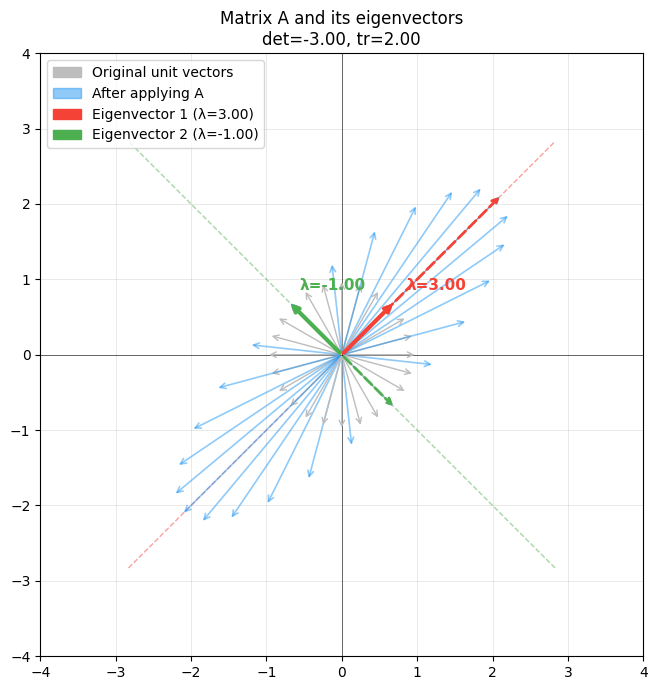

In [10]:
A = np.array([[1, 2], [2, 1]])
vals, _ = np.linalg.eig(A)
print(f"Eigenvalues: {vals}")
plot_eigen_field(A)